# HEST-1k library

source: https://github.com/mahmoodlab/hest


In [ ]:
from huggingface_hub import login

Inspecting dataset

In [2]:
import pandas as pd

local_dir='/Users/me2982/Documents/work/morpho/HEST data' # hest will be dowloaded to this folder
meta_df = pd.read_csv("hf://datasets/MahmoodLab/hest/HEST_v1_3_0.csv")

# Filter the dataframe by organ, oncotree code...
meta_df = meta_df[meta_df['tissue'] == 'Skin']
meta_df = meta_df[meta_df['species'] == 'Mus musculus']
meta_df.head()


,dataset_title,id,image_filename,organ,disease_state,oncotree_code,species,patient,st_technology,data_publication_date,...,treatment_comment,pixel_size_um_embedded,pixel_size_um_estimated,magnification,fullres_px_width,fullres_px_height,tissue,disease_comment,subseries,hest_version_added
62,Nextflow Pipeline for Visium and H&E Data from...,ZEN81,ZEN81.tif,Skin,Cancer,MEL,Mus musculus,NaN,Visium,21-May-24,...,NaN,0.220819,0.220803,40x,35392,36416,Skin,WM4237-1 melanoma PDX,"WM4237-1, mouse 1337, untreated, sample S1",v1_1_0
63,Nextflow Pipeline for Visium and H&E Data from...,ZEN80,ZEN80.tif,Skin,Cancer,MEL,Mus musculus,NaN,Visium,21-May-24,...,NaN,0.220819,0.220377,40x,36096,36992,Skin,WM4237-1 melanoma PDX,"WM4237-1, mouse 1337, untreated, sample S2",v1_1_0
64,Nextflow Pipeline for Visium and H&E Data from...,ZEN79,ZEN79.tif,Skin,Cancer,MEL,Mus musculus,NaN,Visium,21-May-24,...,NaN,0.220819,0.220804,40x,36288,36544,Skin,WM4237-1 melanoma PDX,"WM4237-1, mouse 1337, untreated, sample S3",v1_1_0
65,Nextflow Pipeline for Visium and H&E Data from...,ZEN78,ZEN78.tif,Skin,Cancer,MEL,Mus musculus,NaN,Visium,21-May-24,...,NaN,0.220819,0.220768,40x,35904,36608,Skin,WM4237-1 melanoma PDX,"WM4237-1, mouse 1337, untreated, sample S4",v1_1_0
265,Demo 10x Visium dataset for STQ,ZEN65,ZEN65.tif,Skin,Cancer,MEL,Mus musculus,NaN,Visium,31-May-24,...,NaN,0.220819,0.220750,40x,35392,36416,Skin,BRAF V600E mutant,Demo,v1_0_0


In [4]:
import os
import zipfile

from huggingface_hub import snapshot_download
from tqdm import tqdm

def download_hest(patterns, local_dir):
    repo_id = 'MahmoodLab/hest'
    snapshot_download(repo_id=repo_id, allow_patterns=patterns, repo_type="dataset", local_dir=local_dir)

    seg_dir = os.path.join(local_dir, 'cellvit_seg')
    if os.path.exists(seg_dir):
        print('Unzipping cell vit segmentation...')
        for filename in tqdm([s for s in os.listdir(seg_dir) if s.endswith('.zip')]):
            path_zip = os.path.join(seg_dir, filename)
                        
            with zipfile.ZipFile(path_zip, 'r') as zip_ref:
                zip_ref.extractall(seg_dir)

In [3]:
local_dir='/Users/me2982/Documents/work/morpho/HEST data' # hest will be dowloaded to this folder
ids_to_download = ["*ZEN81*"]
ids = ["ZEN81"]
# download_hest(ids_to_download, local_dir)


In [5]:
from hest import iter_hest
# Iterate through a subset of hest
for st in iter_hest(local_dir, ids):

    # ST (adata):
    adata = st.adata
    print('\n* Scanpy adata:')
    print(adata)

    # WSI:
    wsi = st.wsi
    print('\n* WSI:')
    print(wsi)
    
    # Shapes:
    shapes = st.shapes
    print('\n* Shapes:')
    print(shapes)
    
    # Tissue segmentation
    tissue_contours = st.tissue_contours
    print('\n* Tissue contours:')
    print(tissue_contours)
    
    # Conversion to SpatialData
    sdata = st.to_spatial_data()
    print('\n* SpatialData conversion:')
    print(sdata)

/Users/me2982/Documents/GitHub/multimodal-rep/HEST/src/hest/HESTData.py:1195: RuntimeWarning: CuCIM backend is not available; falling back to default WSI readers.
  CucimWarningSingleton.warn()



* Scanpy adata:
AnnData object with n_obs × n_vars = 4991 × 68886
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito'
    var: 'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mito'
    uns: 'spatial'
    obsm: 'spatial'

* WSI:
<width=35392, height=36416, backend=ImageWSI, mpp=0.22080276739617732, mag=40>

* Shapes:
[name: cellvit, coord-system: he, <not loaded>]

* Tissue contours:
   tissue_id                                           geometry
0          0  POLYGON ((34896 24303, 34877 24321, 34859 2434...
1          1  POLYGON ((18477 13375, 18459 13357, 18440 1335...


/Users/me2982/miniconda3/envs/hest/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution



* SpatialData conversion:
SpatialData object
├── Images
│     ├── 'ST_downscaled_hires_image': SpatialImage[cyx] (3, 36416, 35392)
│     └── 'ST_downscaled_lowres_image': SpatialImage[cyx] (3, 1000, 972)
├── Shapes
│     ├── 'cellvit': GeoDataFrame shape: (28897, 3) (2D shapes)
│     ├── 'locations': GeoDataFrame shape: (4991, 2) (2D shapes)
│     └── 'tissue_contours': GeoDataFrame shape: (2, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (4991, 68886)
with coordinate systems:
    ▸ 'ST_downscaled_hires', with elements:
        ST_downscaled_hires_image (Images), cellvit (Shapes), locations (Shapes), tissue_contours (Shapes)
    ▸ 'ST_downscaled_lowres', with elements:
        ST_downscaled_lowres_image (Images), cellvit (Shapes), locations (Shapes), tissue_contours (Shapes)


/Users/me2982/miniconda3/envs/hest/lib/python3.11/site-packages/spatialdata/models/models.py:246: UserWarning: Detected chunks larger than: 3866505216 > 2147483647 bytes. This can lead to low performance and memory issues downstream, and sometimes cause compression errors when writing (https://github.com/scverse/spatialdata/issues/812#issuecomment-2575983527). Please consider using 1) smaller chunks and/or 2) using a multiscale representation for the raster data.
1) Smaller chunks can be achieved by using the `chunks` argument in the `parse()` function or by calling the `chunk()` method on `DataArray`/`DataTree` objects.
2) Multiscale representations can be achieved by using the `scale_factors` argument in the `parse()` function.
You can suppress this warning by increasing the value of `spatialdata.settings.large_chunk_threshold_bytes`.
  cls()._check_chunk_size_not_too_large(data)
/Users/me2982/miniconda3/envs/hest/lib/python3.11/site-packages/spatialdata/models/models.py:273: UserWar

/Users/me2982/Documents/GitHub/multimodal-rep/HEST/src/hest/HESTData.py:1589: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(adata, show=False, img_key="downscaled_fullres", color=[key], title=f"in_tissue spots", return_fig=True, **pl_kwargs)


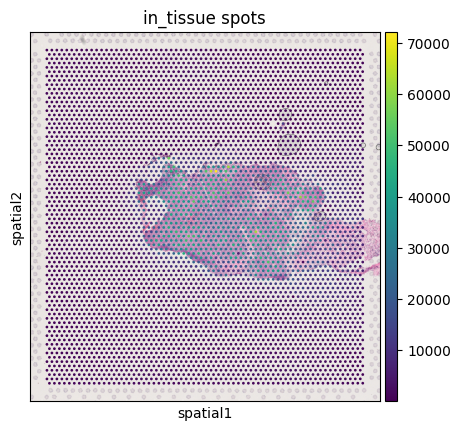

In [6]:
save_dir = '/Users/me2982/Documents/work/morpho/HEST_saved_output'
st.save_spatial_plot(save_dir)

In [8]:
import os
os.environ['DYLD_LIBRARY_PATH'] = '/opt/homebrew/Cellar/vips/8.18.2_1/lib:' + os.environ.get('DYLD_LIBRARY_PATH', '')

import ctypes
ctypes.CDLL('/opt/homebrew/Cellar/vips/8.18.2_1/lib/libvips.42.dylib')

import pyvips
print(pyvips.__version__)

objc[4279]: Class GNotificationCenterDelegate is implemented in both /Users/me2982/miniconda3/envs/hest/lib/python3.11/site-packages/openslide_bin/libopenslide.1.dylib (0x15dca91a0) and /opt/homebrew/Cellar/glib/2.88.1/lib/libgio-2.0.0.dylib (0x38604c4c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


3.1.1


In [9]:
import pyvips
# Warning saving a large image to pyramidal tiff (>1GB) can be slow on a hard drive.
st.save(save_dir, pyramidal=True)

saving to pyramidal tiff... can be slow
